<a href="https://colab.research.google.com/github/Merced-College/arduinoPBL/blob/main/ML_Accelerometer_Game/ML_Accelerometer_Game.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# 🧠 Gesture Classification Lab (Punch vs Flex)

In this lab, you will train a machine learning model using data from the Arduino Nano 33 BLE Sense Rev2 to recognize **punch** and **flex** gestures.

### ✅ Before moving on, make sure:
- Your model trains without errors (no `NaN`)
- Training/validation graphs appear
- Predictions look like probabilities (e.g., `[0.98, 0.02]`)
- The model correctly classifies most test samples

👉 If everything looks good, download your `model.h` and move on to the Arduino + web game portion.

## Setup Python Environment

The next cell sets up the dependencies in required for the notebook, run it.

In [30]:
# Setup environment
!apt-get -qq install xxd
!pip install pandas numpy matplotlib
!pip install tensorflow==2.0.0-rc1

ERROR: Could not find a version that satisfies the requirement tensorflow==2.0.0-rc1 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.0.0-rc1


# Upload Data

1. Open the panel on the left side of Colab by clicking on the __>__
1. Select the files tab
1. Drag `punch.csv` and `flex.csv` files from your computer to the tab to upload them into colab.

# Graph Data (optional)

We'll graph the input files on two separate graphs, acceleration and gyroscope, as each data set has different units and scale.

/tmp/ipykernel_13667/3982237304.py:13: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aX'], 'g.', label='x', linestyle='solid', marker=',')
/tmp/ipykernel_13667/3982237304.py:14: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aY'], 'b.', label='y', linestyle='solid', marker=',')
/tmp/ipykernel_13667/3982237304.py:15: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "r." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aZ'], 'r.', label='z', linestyle='solid', marker=',')


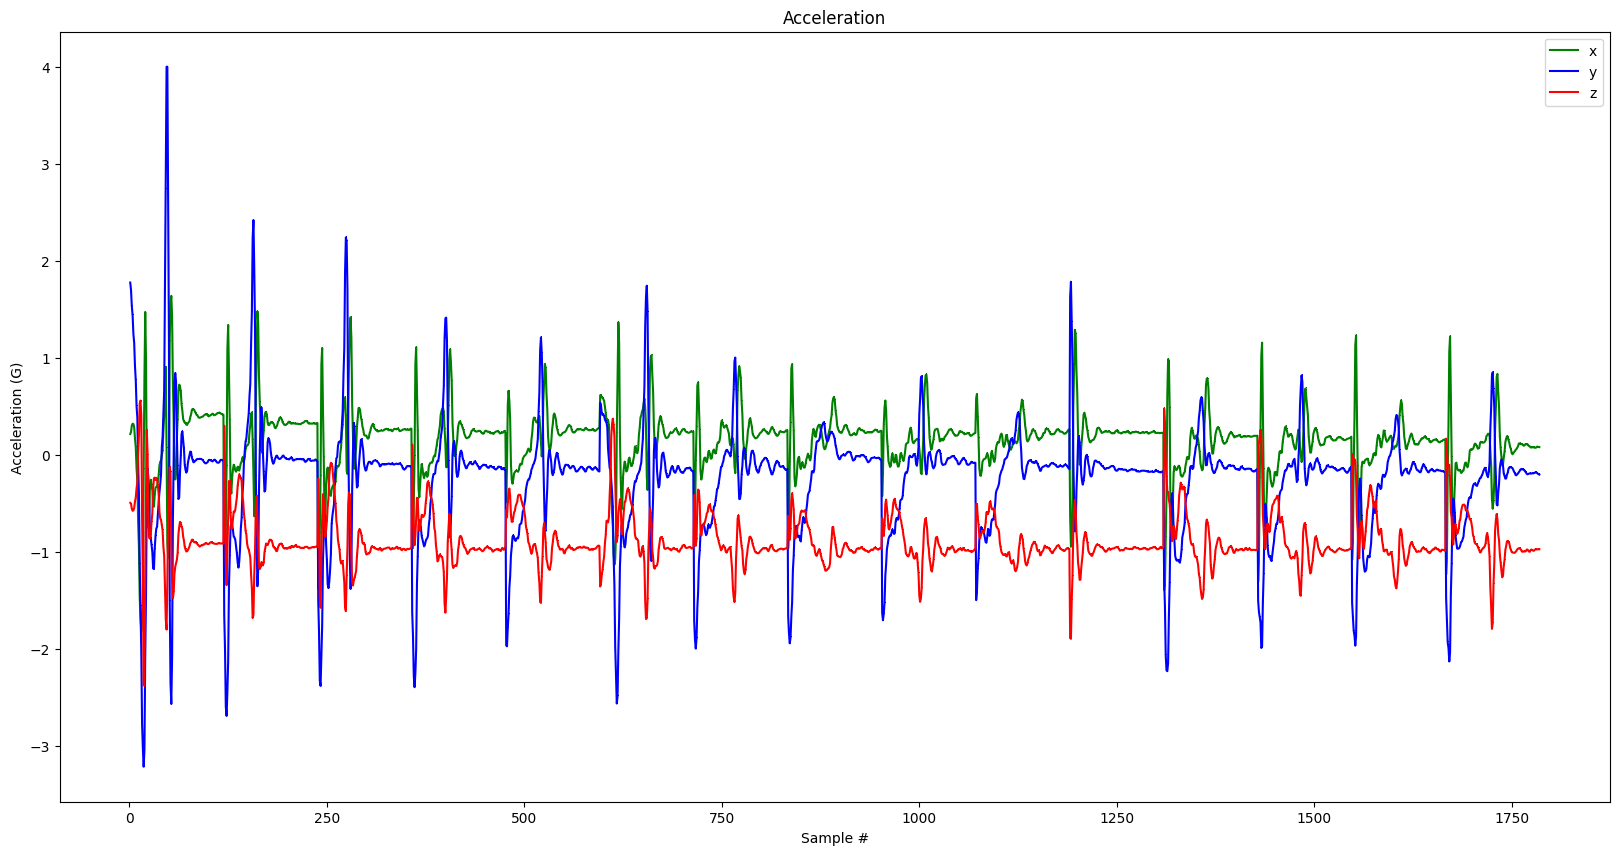

/tmp/ipykernel_13667/3982237304.py:22: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gX'], 'g.', label='x', linestyle='solid', marker=',')
/tmp/ipykernel_13667/3982237304.py:23: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gY'], 'b.', label='y', linestyle='solid', marker=',')
/tmp/ipykernel_13667/3982237304.py:24: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "r." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gZ'], 'r.', label='z', linestyle='solid', marker=',')


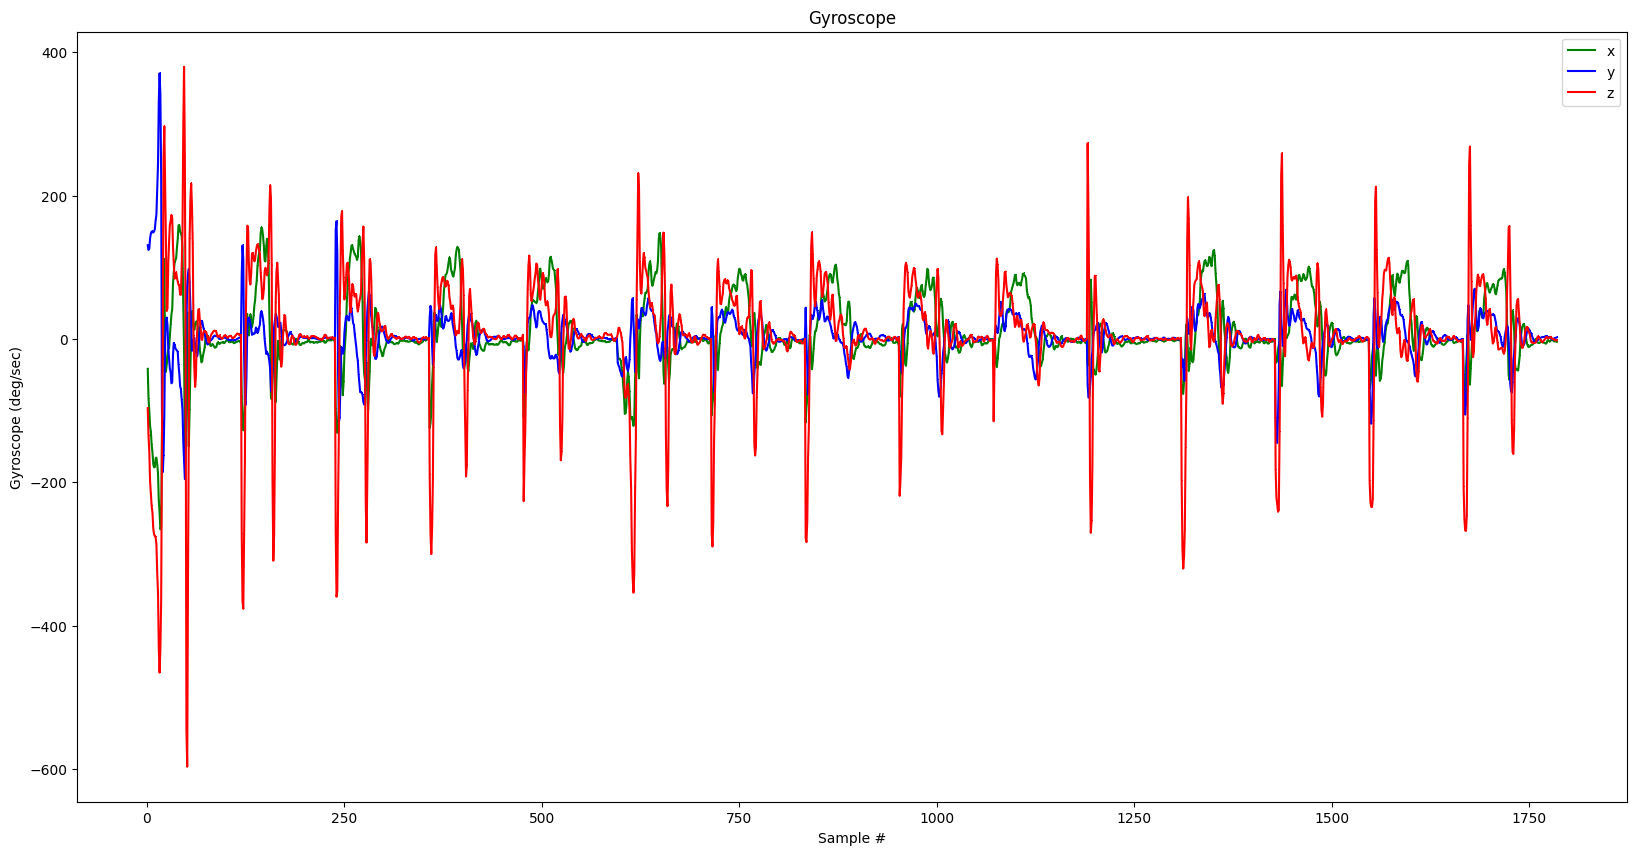

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

filename = "punch.csv"

df = pd.read_csv("/content/" + filename)

index = range(1, len(df['aX']) + 1)

plt.rcParams["figure.figsize"] = (20,10)

plt.plot(index, df['aX'], 'g.', label='x', linestyle='solid', marker=',')
plt.plot(index, df['aY'], 'b.', label='y', linestyle='solid', marker=',')
plt.plot(index, df['aZ'], 'r.', label='z', linestyle='solid', marker=',')
plt.title("Acceleration")
plt.xlabel("Sample #")
plt.ylabel("Acceleration (G)")
plt.legend()
plt.show()

plt.plot(index, df['gX'], 'g.', label='x', linestyle='solid', marker=',')
plt.plot(index, df['gY'], 'b.', label='y', linestyle='solid', marker=',')
plt.plot(index, df['gZ'], 'r.', label='z', linestyle='solid', marker=',')
plt.title("Gyroscope")
plt.xlabel("Sample #")
plt.ylabel("Gyroscope (deg/sec)")
plt.legend()
plt.show()


# Train Neural Network





## Parse and prepare the data

The next cell parses the csv files and transforms them to a format that will be used to train the fully connected neural network.

Update the `GESTURES` list with the gesture data you've collected in `.csv` format.


In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

print(f"TensorFlow version = {tf.__version__}\n")

SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

GESTURES = [
    "punch",
    "flex",
]

SAMPLES_PER_GESTURE = 119
NUM_GESTURES = len(GESTURES)
ONE_HOT_ENCODED_GESTURES = np.eye(NUM_GESTURES)

inputs = []
outputs = []

for gesture_index, gesture in enumerate(GESTURES):
    print(f"Processing gesture: {gesture}")

    output = ONE_HOT_ENCODED_GESTURES[gesture_index]

    df = pd.read_csv("/content/" + gesture + ".csv")

    expected_cols = ["aX", "aY", "aZ", "gX", "gY", "gZ"]
    df = df[expected_cols].copy()

    for col in expected_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna().reset_index(drop=True)

    print(f"  Rows after cleanup: {df.shape[0]}")

    if df.shape[0] % SAMPLES_PER_GESTURE != 0:
        raise ValueError(
            f"{gesture}.csv has {df.shape[0]} usable rows, which is not divisible by "
            f"SAMPLES_PER_GESTURE={SAMPLES_PER_GESTURE}"
        )

    num_recordings = df.shape[0] // SAMPLES_PER_GESTURE
    print(f"  Number of recordings: {num_recordings}")

    for i in range(num_recordings):
        start = i * SAMPLES_PER_GESTURE
        end = start + SAMPLES_PER_GESTURE
        recording = df.iloc[start:end]

        tensor = []
        for _, row in recording.iterrows():
            tensor += [
                (row["aX"] + 4.0) / 8.0,
                (row["aY"] + 4.0) / 8.0,
                (row["aZ"] + 4.0) / 8.0,
                (row["gX"] + 2000.0) / 4000.0,
                (row["gY"] + 2000.0) / 4000.0,
                (row["gZ"] + 2000.0) / 4000.0,
            ]

        inputs.append(tensor)
        outputs.append(output)

inputs = np.array(inputs, dtype=np.float32)
outputs = np.array(outputs, dtype=np.float32)

print("\nData set parsing and preparation complete.")
print("inputs shape:", inputs.shape)
print("outputs shape:", outputs.shape)
print("Any NaN in inputs?", np.isnan(inputs).any())
print("Any NaN in outputs?", np.isnan(outputs).any())
print("Input min:", np.min(inputs))
print("Input max:", np.max(inputs))

TensorFlow version = 2.19.0

Processing gesture: punch
  Rows after cleanup: 1785
  Number of recordings: 15
Processing gesture: flex
  Rows after cleanup: 1785
  Number of recordings: 15

Data set parsing and preparation complete.
inputs shape: (30, 714)
outputs shape: (30, 2)
Any NaN in inputs? False
Any NaN in outputs? False
Input min: 0.0
Input max: 1.0


## Randomize and split the input and output pairs for training

Randomly split input and output pairs into sets of data: 60% for training, 20% for validation, and 20% for testing.

  - the training set is used to train the model
  - the validation set is used to measure how well the model is performing during training
  - the testing set is used to test the model after training

In [33]:
num_inputs = len(inputs)
randomize = np.arange(num_inputs)
np.random.shuffle(randomize)

inputs = inputs[randomize]
outputs = outputs[randomize]

TRAIN_SPLIT = int(0.6 * num_inputs)
TEST_SPLIT = int(0.8 * num_inputs)

inputs_train, inputs_test, inputs_validate = np.split(inputs, [TRAIN_SPLIT, TEST_SPLIT])
outputs_train, outputs_test, outputs_validate = np.split(outputs, [TRAIN_SPLIT, TEST_SPLIT])

print("Data set randomization and splitting complete.")
print("inputs_train:", inputs_train.shape)
print("inputs_test:", inputs_test.shape)
print("inputs_validate:", inputs_validate.shape)
print("outputs_train:", outputs_train.shape)
print("outputs_test:", outputs_test.shape)
print("outputs_validate:", outputs_validate.shape)

Data set randomization and splitting complete.
inputs_train: (18, 714)
inputs_test: (6, 714)
inputs_validate: (6, 714)
outputs_train: (18, 2)
outputs_test: (6, 2)
outputs_validate: (6, 2)


## Build & Train the Model

Build and train a [TensorFlow](https://www.tensorflow.org) model using the high-level [Keras](https://www.tensorflow.org/guide/keras) API.

In [34]:
import numpy as np

print("inputs_train shape:", inputs_train.shape)
print("outputs_train shape:", outputs_train.shape)
print("inputs_validate shape:", inputs_validate.shape)
print("outputs_validate shape:", outputs_validate.shape)

print("Any NaN in inputs_train?", np.isnan(inputs_train).any())
print("Any NaN in outputs_train?", np.isnan(outputs_train).any())
print("Any NaN in inputs_validate?", np.isnan(inputs_validate).any())
print("Any NaN in outputs_validate?", np.isnan(outputs_validate).any())

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(inputs_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(NUM_GESTURES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    inputs_train,
    outputs_train,
    epochs=200,
    batch_size=4,
    validation_data=(inputs_validate, outputs_validate),
    callbacks=[early_stop],
    verbose=1
)

inputs_train shape: (18, 714)
outputs_train shape: (18, 2)
inputs_validate shape: (6, 714)
outputs_validate shape: (6, 2)
Any NaN in inputs_train? False
Any NaN in outputs_train? False
Any NaN in inputs_validate? False
Any NaN in outputs_validate? False
Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.6111 - loss: 0.6910 - val_accuracy: 0.3333 - val_loss: 0.8101
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6111 - loss: 0.6542 - val_accuracy: 0.3333 - val_loss: 0.7226
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6111 - loss: 0.6542 - val_accuracy: 0.6667 - val_loss: 0.6696
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.6585 - val_accuracy: 1.0000 - val_loss: 0.6528
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9444 - loss: 0.6534 - val_accuracy: 1.0000 - val_loss: 0.6569
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.6319 - val_accuracy: 1.0000 - val_los

## Verify

Graph the models performance vs validation.


### Graph the loss

Graph the loss to see when the model stops improving.

First 10 training loss values: [0.6910246014595032, 0.6542205214500427, 0.6542456746101379, 0.658537745475769, 0.6534121036529541, 0.6318667531013489, 0.637258768081665, 0.6008127927780151, 0.5447517037391663, 0.5419613122940063]
First 10 validation loss values: [0.8100707530975342, 0.7225937247276306, 0.6695935130119324, 0.6528297066688538, 0.6569252014160156, 0.6064653992652893, 0.5941800475120544, 0.67801833152771, 0.5615351796150208, 0.5031949877738953]


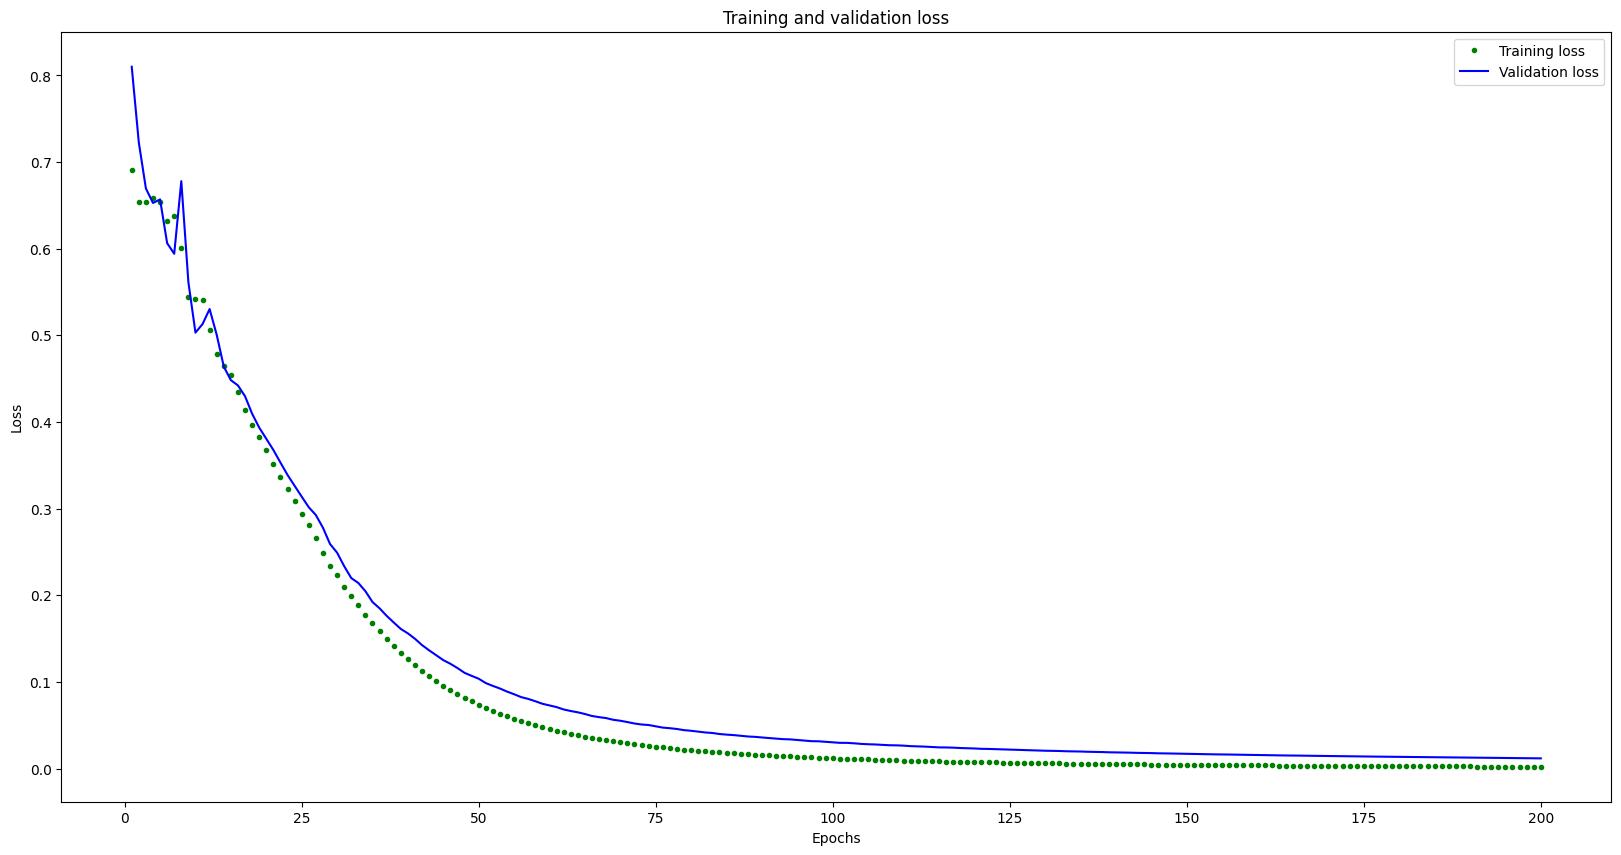

In [35]:
plt.rcParams["figure.figsize"] = (20,10)

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

print("First 10 training loss values:", loss[:10])
print("First 10 validation loss values:", val_loss[:10])

plt.plot(epochs, loss, 'g.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Graph the loss again, skipping a bit of the start

We'll graph the same data as the previous code cell, but start at index 100 so we can further zoom in once the model starts to converge.

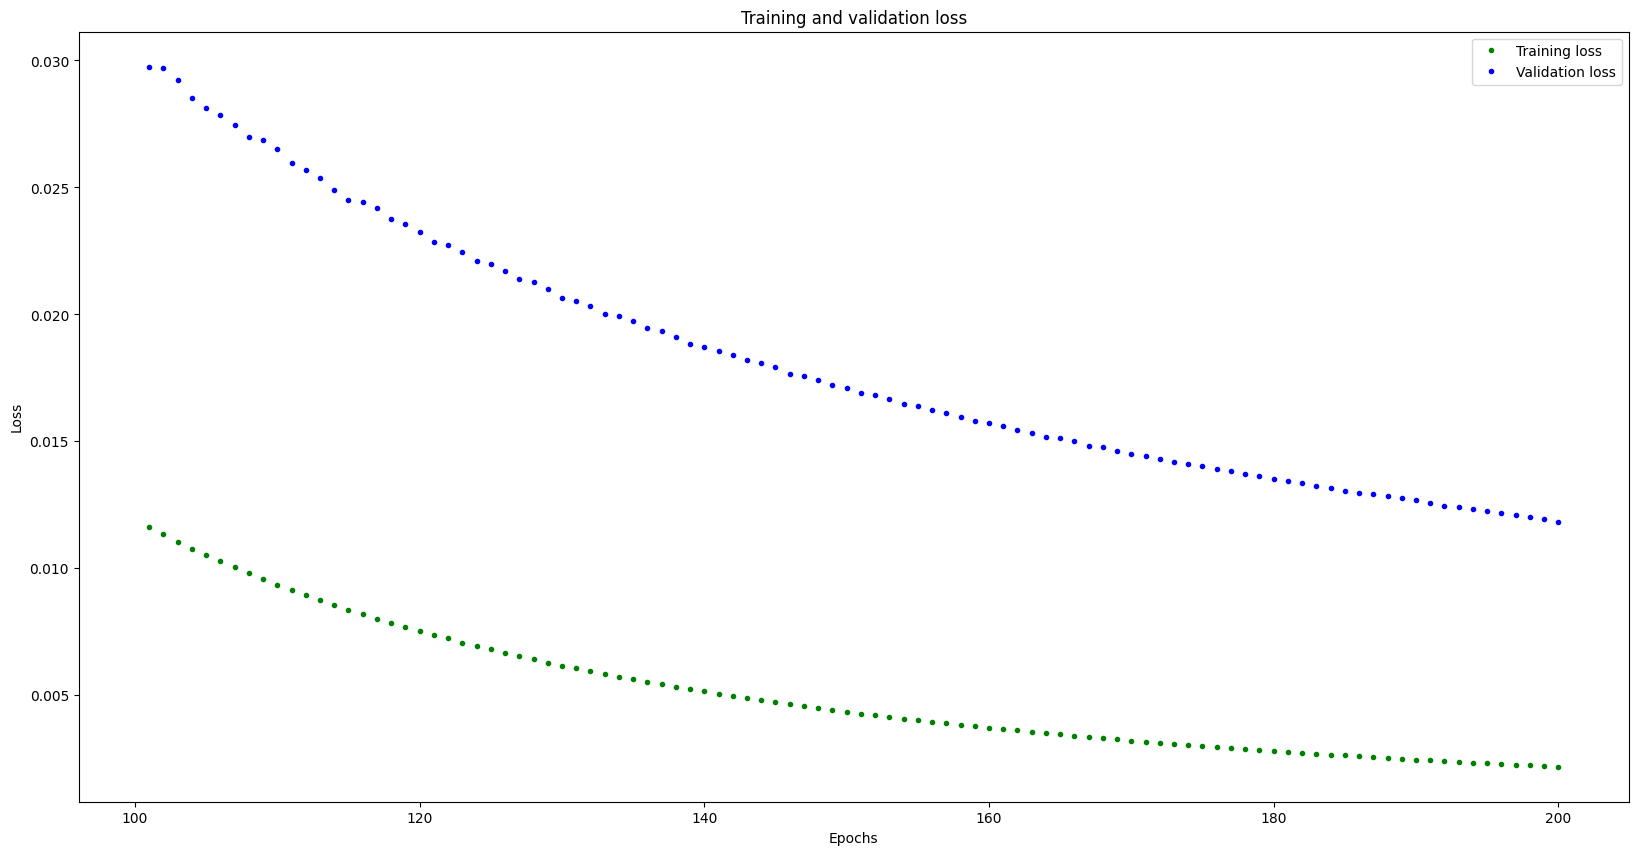

In [36]:
# graph the loss again skipping a bit of the start
SKIP = 100
plt.plot(epochs[SKIP:], loss[SKIP:], 'g.', label='Training loss')
plt.plot(epochs[SKIP:], val_loss[SKIP:], 'b.', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Graph the mean absolute error

[Mean absolute error](https://en.wikipedia.org/wiki/Mean_absolute_error) is another metric to judge the performance of the model.



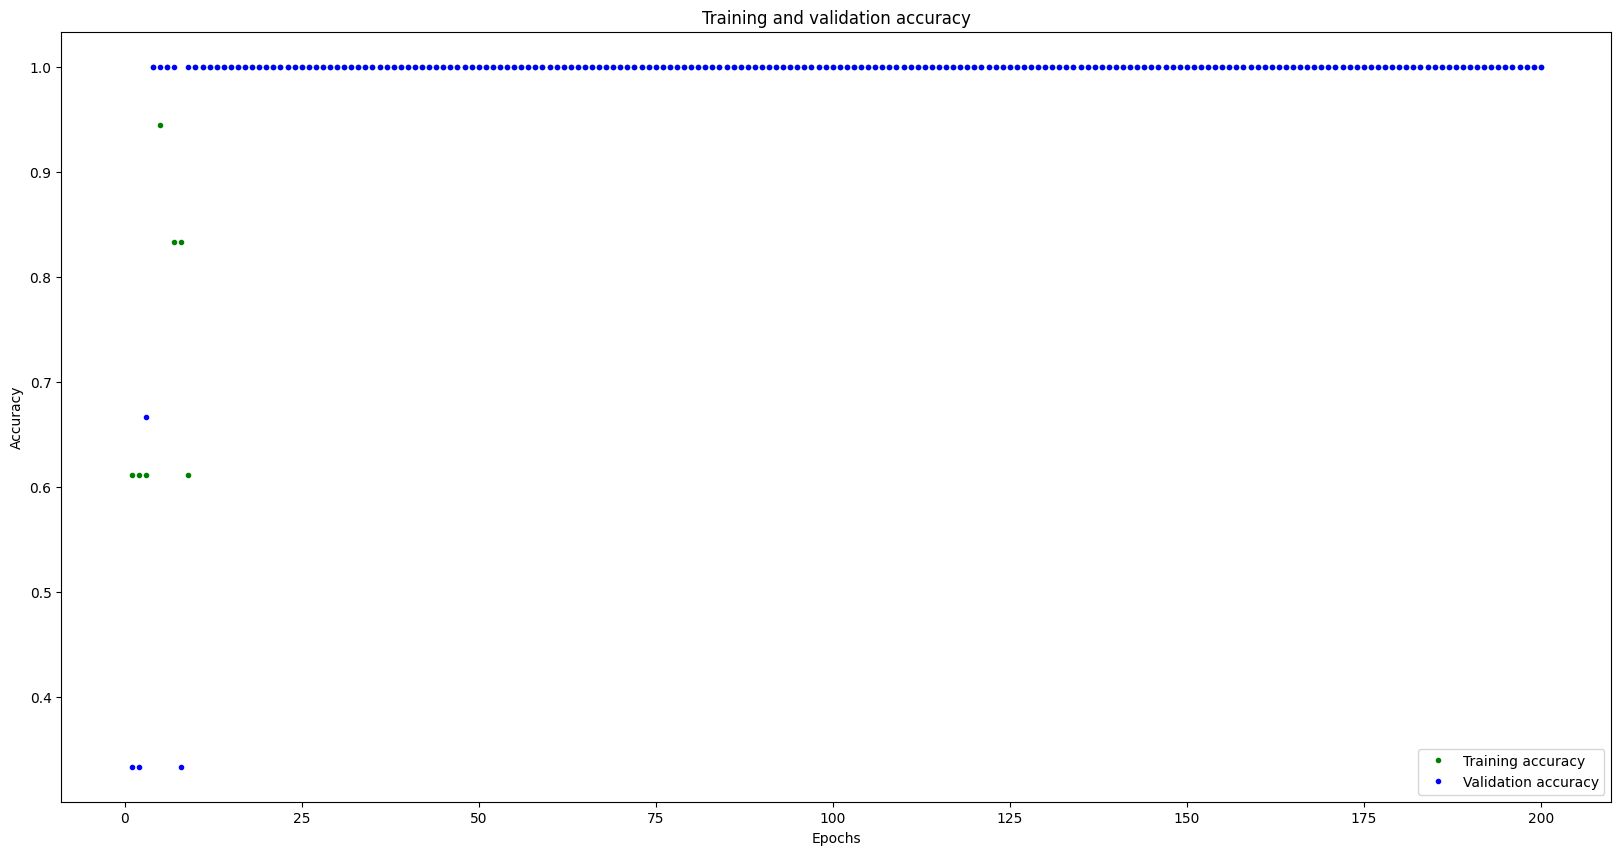

In [37]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, 'g.', label='Training accuracy')
plt.plot(epochs, val_acc, 'b.', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Run with Test Data
Put our test data into the model and plot the predictions


In [38]:
predictions = model.predict(inputs_test)

print("predictions =\n", np.round(predictions, 3))
print("actual =\n", outputs_test)

predicted_labels = np.argmax(predictions, axis=1)
actual_labels = np.argmax(outputs_test, axis=1)

print("predicted labels:", predicted_labels)
print("actual labels:   ", actual_labels)

test_accuracy = np.mean(predicted_labels == actual_labels)
print("Test accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
predictions =
 [[0.998 0.002]
 [0.998 0.002]
 [0.002 0.998]
 [0.002 0.998]
 [0.002 0.998]
 [0.002 0.998]]
actual =
 [[1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]
predicted labels: [0 0 1 1 1 1]
actual labels:    [0 0 1 1 1 1]
Test accuracy: 1.0


# Convert the Trained Model to Tensor Flow Lite

The next cell converts the model to TFlite format. The size in bytes of the model is also printed out.

In [39]:
# Convert the model to the TensorFlow Lite format without quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the model to disk
open("gesture_model.tflite", "wb").write(tflite_model)

import os
basic_model_size = os.path.getsize("gesture_model.tflite")
print("Model is %d bytes" % basic_model_size)



Saved artifact at '/tmp/tmpg1ki28pf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 714), dtype=tf.float32, name='keras_tensor_20')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  137018338868112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137018338861008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137018338863696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137018338868496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137018221803856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137018221802320: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model is 95904 bytes


## Encode the Model in an Arduino Header File

The next cell creates a constant byte array that contains the TFlite model. Import it as a tab with the sketch below.

In [40]:
!echo "const unsigned char model[] = {" > /content/model.h
!cat gesture_model.tflite | xxd -i      >> /content/model.h
!echo "};"                              >> /content/model.h

import os
model_h_size = os.path.getsize("model.h")
print(f"Header file, model.h, is {model_h_size:,} bytes.")
print("\nOpen the side panel (refresh if needed). Double click model.h to download the file.")

Header file, model.h, is 591,442 bytes.

Open the side panel (refresh if needed). Double click model.h to download the file.


# Classifying IMU Data

Now it's time to switch back to the tutorial instructions and run our new model on the Arduino Nano 33 BLE Sense to classify the accelerometer and gyroscope data.


🧠 Gesture Classification Check (Punch vs Flex)

In this lab, you trained a machine learning model using data from the Arduino Nano 33 BLE Sense Rev2 to recognize two gestures: punch and flex.

Before moving on to deploy your model to the Arduino, you must verify that your data and model trained correctly.

✅ Checklist Before Moving On
📁 Data
CSV files have header: aX,aY,aZ,gX,gY,gZ
No blank rows or missing values (NaN)
Each gesture has multiple recordings (10–15 recommended)
Each recording has the same number of samples (119)
🧪 Data Check (in Colab)

When you run the checking code, confirm:

No NaN values in inputs or outputs
Input values are in a reasonable range (about 0–1 after normalization)
Dataset shapes look correct (multiple recordings per gesture)
📈 Model Training
Training and validation loss graphs appear (not blank)
Loss values are real numbers (not nan)
Accuracy graph shows improvement over time
🎯 Predictions

Model outputs probabilities like:

[0.98, 0.02] → punch
[0.01, 0.99] → flex
Predicted labels mostly match actual labels
🚀 Ready to Continue?

If all checks above look good, your model is working correctly and you are ready to:

Export the model
Upload it to your Arduino
Trigger emoji output from your gestures

👉 If something looks wrong (blank graphs, nan, poor predictions), fix your data or training before continuing.

In [41]:
print(history.history['loss'][-5:])
print(history.history['val_loss'][-5:])
predictions = model.predict(inputs_test)
print(predictions)
print(outputs_test)

[0.0022931566927582026, 0.0022657092195004225, 0.002238551387563348, 0.002211010316386819, 0.002186496974900365]
[0.012172546237707138, 0.012101245112717152, 0.012032966129481792, 0.011925183236598969, 0.011839681304991245]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
[[0.9983668  0.00163325]
 [0.997886   0.00211394]
 [0.00169718 0.9983028 ]
 [0.00177618 0.99822384]
 [0.00207281 0.9979272 ]
 [0.00171832 0.9982817 ]]
[[1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]


This lab was adapted from:

<a href="https://www.arduino.cc/"><img src="https://raw.githubusercontent.com/sandeepmistry/aimldevfest-workshop-2019/master/images/Arduino_logo_R_highquality.png" width=200/></a>
# Tiny ML on Arduino
## Gesture recognition tutorial
 * Sandeep Mistry - Arduino
 * Don Coleman - Chariot Solutions


https://github.com/arduino/ArduinoTensorFlowLiteTutorials/